# Racing Lap Time Analysis

## Project Overview

This project uses machine learning regression models to predict racing lap times.

The dataset contains numerical information related to racing conditions, including average speed, tyre wear, track temperature, wind speed, and pit stop status.

The project includes exploratory data analysis and compares three regression models:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The models are evaluated using R², MAE, and RMSE.

In [64]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

In [65]:
df=pd.read_csv("racing_lap_times_numeric.csv")

In [66]:
df.head()

,avg_speed_kmh,tyre_wear_pct,track_temp_c,wind_speed_mps,pit_stop_flag,lap_time_sec
0,174.577,27.026,31.524,2.270,0,75.822
1,172.009,32.162,24.800,1.936,1,88.448
2,185.208,27.187,33.752,3.037,1,87.322
3,183.022,42.911,34.703,2.728,1,86.379
4,163.143,36.438,20.245,1.583,1,86.942


In [67]:
df.describe()

,avg_speed_kmh,tyre_wear_pct,track_temp_c,wind_speed_mps,pit_stop_flag,lap_time_sec
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,180.193454,25.117428,29.724337,2.032772,0.491000,80.210206
std,11.959602,8.052854,5.010266,1.114196,0.500044,6.456283
min,143.235000,0.000000,11.758000,0.000000,0.000000,63.928000
25%,171.954500,19.654000,26.400250,1.226500,0.000000,74.269250
50%,180.164000,25.199000,29.888000,1.927500,0.000000,79.281500
75%,188.193750,30.241750,32.997250,2.797000,1.000000,86.278000
max,217.062000,52.632000,45.894000,5.953000,1.000000,94.282000


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   avg_speed_kmh   2000 non-null   float64
 1   tyre_wear_pct   2000 non-null   float64
 2   track_temp_c    2000 non-null   float64
 3   wind_speed_mps  2000 non-null   float64
 4   pit_stop_flag   2000 non-null   int64  
 5   lap_time_sec    2000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 93.9 KB


## Dataset Exploration

The dataset is inspected using basic statistical summaries, data types, missing-value checks, and visualizations.

The main target variable is `lap_time_sec`, which represents the lap time in seconds.

In [69]:
df.isna().sum()

avg_speed_kmh     0
tyre_wear_pct     0
track_temp_c      0
wind_speed_mps    0
pit_stop_flag     0
lap_time_sec      0
dtype: int64

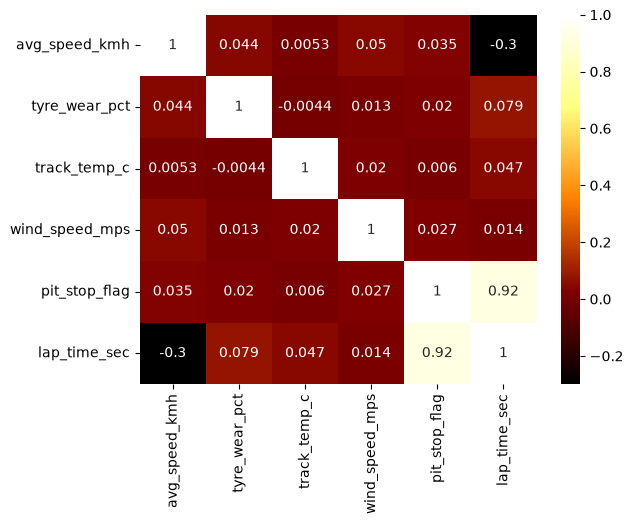

In [70]:
sns.heatmap(df.corr(),cmap="afmhot",annot=True)
plt.show()

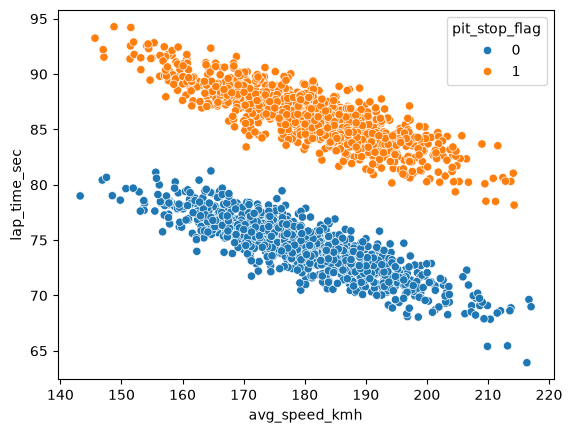

In [71]:
sns.scatterplot(data=df,x="avg_speed_kmh",y="lap_time_sec",hue="pit_stop_flag")
plt.show()

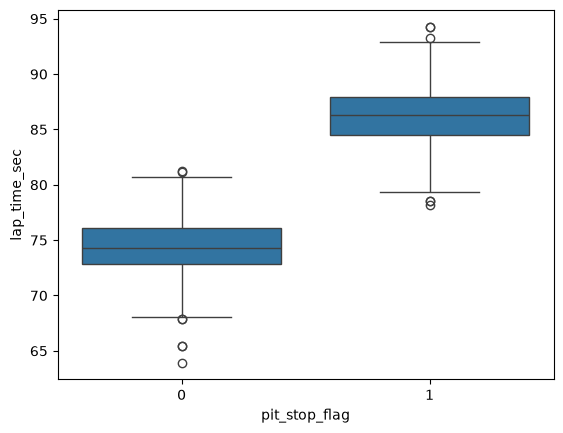

In [72]:
sns.boxplot(data=df,x="pit_stop_flag",y="lap_time_sec")
plt.show()

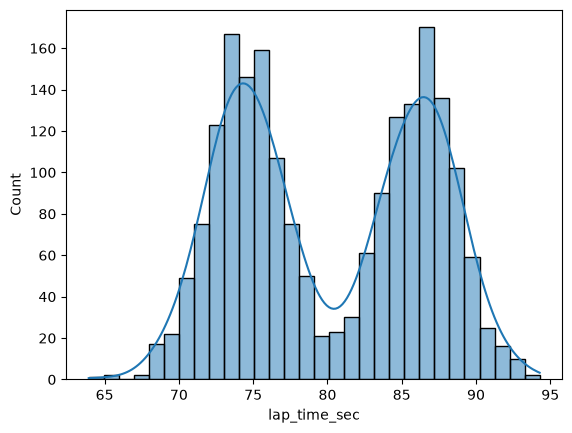

In [73]:
sns.histplot(data=df,x="lap_time_sec",bins=30,kde=True)
plt.show()

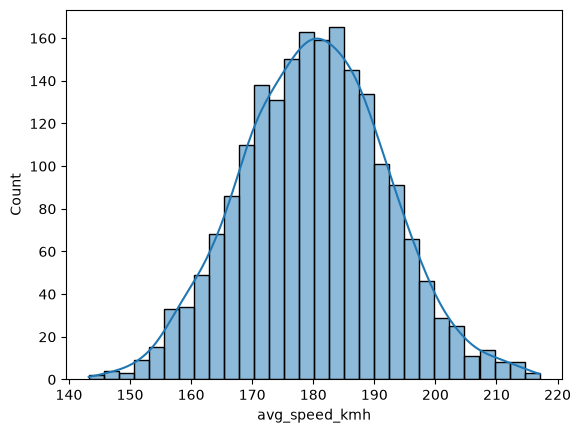

In [74]:
sns.histplot(data=df,x="avg_speed_kmh",bins=30,kde=True)
plt.show()

## Machine Learning

The target variable is `lap_time_sec`.

The remaining numerical columns are used as input features.

The dataset is divided into training and testing sets using an 80/20 split.

In [75]:
X= df.drop("lap_time_sec",axis=1)
y= df["lap_time_sec"]

In [76]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## Linear Regression

Linear Regression is used as a baseline regression model for predicting lap time.

In [77]:
linear_model = LinearRegression()

In [78]:
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.18, 0.06, 0.06, 0.03,12.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['avg_speed_kmh','tyre_wear_pct','track_temp_c','wind_speed_mps', 'pit_stop_flag']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,104
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [79]:
y_pred_linear=linear_model.predict(X_test)

In [80]:
linear_r2 = r2_score(y_test, y_pred_linear)
mae_linear_model=mean_absolute_error(y_test,y_pred_linear)
rmse_linear_model = mean_squared_error(y_test, y_pred_linear) ** 0.5

print("Linear Regression R2:",r2_score(y_test,y_pred_linear))
print("Linear Regression MAE:",mae_linear_model)
print("Linear Regression RMSE:",rmse_linear_model)

Linear Regression R2: 0.9653049784206293
Linear Regression MAE: 0.9671268199012042
Linear Regression RMSE: 1.1926399359035753


## Decision Tree Regressor

A Decision Tree Regressor is trained to model non-linear relationships between the input features and lap time.

In [81]:
dtree_model=DecisionTreeRegressor(random_state=42)

In [82]:
dtree_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [83]:
y_pred_dtree=dtree_model.predict(X_test)

In [84]:
dtree_r2 = r2_score(y_test, y_pred_dtree)
mae_dtree_model=mean_absolute_error(y_test,y_pred_dtree)
rmse_dtree_model = mean_squared_error(y_test, y_pred_dtree) ** 0.5

print("Decision Tree R2:",r2_score(y_test,y_pred_dtree))
print("Decision Tree MAE:",mae_dtree_model)
print("Decision Tree RMSE:",rmse_dtree_model)

Decision Tree R2: 0.9160487938933823
Decision Tree MAE: 1.4904724999999999
Decision Tree RMSE: 1.8551935970404811


## Random Forest Regressor

Random Forest combines multiple decision trees to improve predictive performance and reduce dependence on a single tree.

In [85]:
random_model=RandomForestRegressor(random_state=42)

In [86]:
random_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [87]:
y_pred_random=random_model.predict(X_test)

In [88]:
random_r2 = r2_score(y_test, y_pred_random)
mae_random_model=mean_absolute_error(y_test,y_pred_random)
rmse_random_model = mean_squared_error(y_test, y_pred_random) ** 0.5

print("Random Forest R2:",random_r2)
print("Random Forest MAE:",mae_random_model)
print("Random Forest RMSE:",rmse_random_model)

Random Forest R2: 0.9602099180008096
Random Forest MAE: 1.0270972249999988
Random Forest RMSE: 1.2772125691944343


## Model Comparison

The performance of the three regression models is compared using R², MAE, and RMSE.

In [89]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2": [
        linear_r2,
        dtree_r2,
        random_r2
    ],
    "MAE": [
        mae_linear_model,
        mae_dtree_model,
        mae_random_model
    ],
    "RMSE": [
        rmse_linear_model,
        rmse_dtree_model,
        rmse_random_model
    ]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.965305,0.967127,1.192640
1,Decision Tree,0.916049,1.490472,1.855194
2,Random Forest,0.960210,1.027097,1.277213


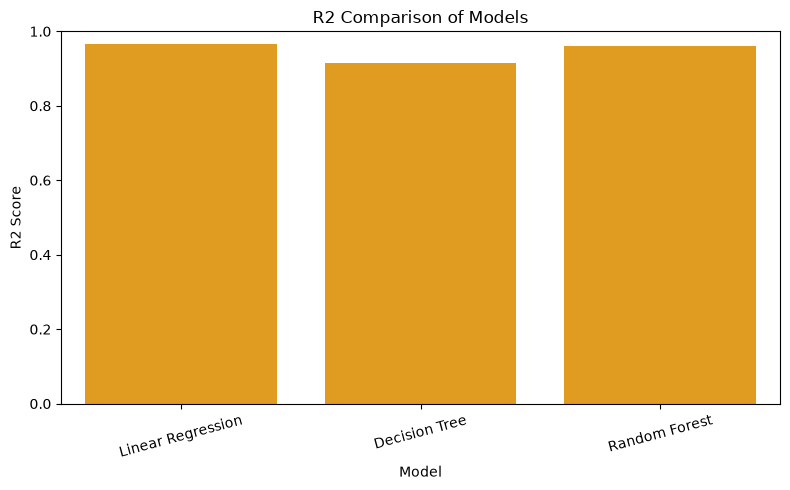

In [90]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="R2",
    color="orange"
)

plt.title("R2 Comparison of Models")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Conclusion

This project demonstrates a complete machine learning regression workflow, from data exploration and visualization to model training and evaluation.

The three regression models are compared using R², MAE, and RMSE. The final results provide a basis for understanding how different regression algorithms perform on the racing lap time dataset.